### Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

sns.set_style('whitegrid')
## Recovering the main path to the project
## In .py files, you can use the following code to get the main path of the project:
##sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..', '..')))
## main_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '..', '..'))

## In .ipynb files, you can use this:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
main_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
# print(f"Main path: {main_path}")



### Functions

In [2]:
##---------------------------------------------------------------------------------------------------- 
# Overview of a column in a dataframe
def descr_column(data, column, count = True):
    print(f'Column: {column}')
    print(f'Number of records in this df: {data.shape[0]}')
    print(f'Number of unique values: {data[column].nunique()}')
    print(f'\nWhat are the unique values: {data[column].unique()}')
    print(f'\nNumber of null values: {data[column].isnull().sum()}')
    print(f'\nPercentage of null values: {round((data[column].isnull().sum()/data.shape[0])* 100,2)} %')
    print(f'\nValue counts: \n{data[column].value_counts()}')


##----------------------------------------------------------------------------------------------------    
## Create a frequency table of a variable in relation to the response variable
## and then build a bar chart
def freq_var(df, columns, col_dic, var_resp_dic):
    tab_freq = df.copy()

    tab_freq = tab_freq[columns]

    tab_freq[columns[0]]= tab_freq[columns[0]].replace(col_dic)

    tab_freq[columns[1]]= tab_freq[columns[1]].replace(var_resp_dic)


    ## Building the frequency table of the variable in relation to the response variable
    tab_freq = tab_freq[[columns[0], columns[1]]].groupby(columns[0]).value_counts()

    tab_graph = tab_freq.copy()
    tab_graph = tab_graph.reset_index()

    ## Not null values of the response variable
    total_passengers = df[df.notnull()[columns[1]]].shape[0]
    tab_freq = round((tab_freq/total_passengers)*100,2)

    sns.barplot(data = tab_graph, y = 'count', x = columns[0], hue = columns[1],palette='Blues_r')

    return(tab_freq)

### Loading data

In [3]:
### Training dataset path
# Relative path to the training dataset
training_data_path = os.path.join(main_path, 'data', 'train.csv')

train_df = pd.read_csv(training_data_path)
train_df['Df'] = 'train'
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


In [4]:
# Relative path to the test dataset
test_data_path = os.path.join(main_path, 'data', 'test.csv')
test_df = pd.read_csv(test_data_path)

test_df['Df'] = 'test'
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,test
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,test
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,test
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,test
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,test


In [5]:
# A single dataframe with both train and test datasets
titanic_df = pd.concat([train_df,test_df], ignore_index=True)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


### Survived - Target Variable

In [6]:
descr_column(titanic_df, 'Survived')

Column: Survived
Number of records in this df: 1309
Number of unique values: 2

What are the unique values: [ 0.  1. nan]

Number of null values: 418

Percentage of null values: 31.93 %

Value counts: 
Survived
0.0    549
1.0    342
Name: count, dtype: int64


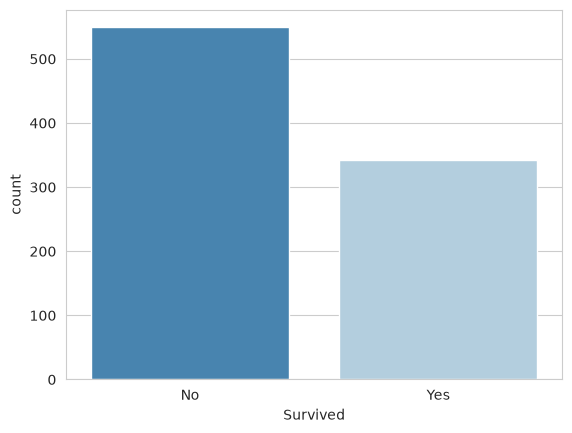

In [7]:
### Graphical representation of the response variable
var_resp_dic = {0:"No",
                1:"Yes"}
tab_graph = titanic_df.copy()
tab_graph['Survived']= tab_graph['Survived'].replace(var_resp_dic)
sns.countplot(data = tab_graph, x = 'Survived',palette='Blues_r')

del tab_graph

### Pclass

In [8]:
descr_column(titanic_df, 'Pclass')

Column: Pclass
Number of records in this df: 1309
Number of unique values: 3

What are the unique values: [3 1 2]

Number of null values: 0

Percentage of null values: 0.0 %

Value counts: 
Pclass
3    709
1    323
2    277
Name: count, dtype: int64


Pclass        Survived
First_Class   Yes         15.26
              No           8.98
Second_Class  No          10.89
              Yes          9.76
Third_Class   No          41.75
              Yes         13.36
Name: count, dtype: float64

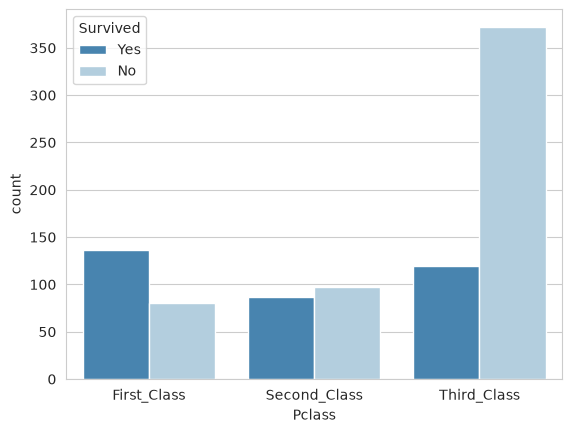

In [9]:
## Analyzing the variable Pclass in relation to the response variable Survived
columns = ['Pclass','Survived']

col_dic = {1:"First_Class",
            2:"Second_Class",
            3:"Third_Class"}
var_resp_dic = {0:"No",
                1:"Yes"}

freq_var(titanic_df, columns, col_dic, var_resp_dic)

The graph shows that First Class was the only passenger class in which the number of survivors exceeded the number of non-survivors. In contrast, Third Class had by far the highest number of deaths, with approximately 370 non-survivors compared with around 120 survivors. Second Class showed a more balanced distribution, although non-survivors still slightly outnumbered survivors. Overall, the data suggests a clear relationship between passenger class and survival, with First Class passengers having the most favorable outcomes and Third Class passengers experiencing the highest number of deaths.

### Sex

In [10]:
descr_column(titanic_df, 'Sex')

Column: Sex
Number of records in this df: 1309
Number of unique values: 2

What are the unique values: <StringArray>
['male', 'female']
Length: 2, dtype: str

Number of null values: 0

Percentage of null values: 0.0 %

Value counts: 
Sex
male      843
female    466
Name: count, dtype: int64


Sex     Survived
female  Yes         26.15
        No           9.09
male    No          52.53
        Yes         12.23
Name: count, dtype: float64

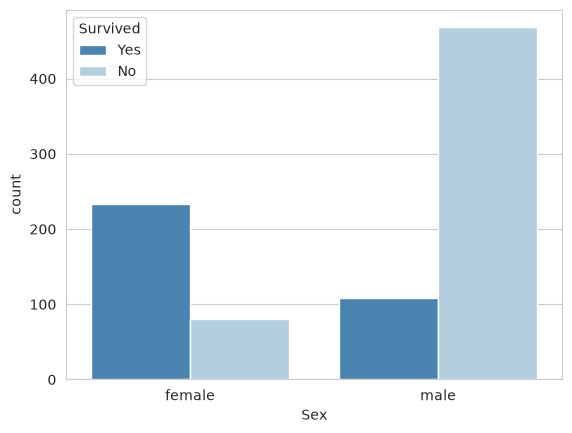

In [11]:
## Analyzing the variable Sex in relation to the response variable Survived
columns = ['Sex','Survived']

col_dic = {'male':'male',
            'female':"female"}

freq_var(titanic_df, columns, col_dic, var_resp_dic)

The chart above demonstrates that women survived longer than men; therefore, the variable Sex can be used to explain the variable Survived in the model. The variables Pclass and Sex do not contain any null values. Therefore, they can be used without any preprocessing.

### Age

In [12]:
## Age
descr_column(titanic_df, 'Age')

Column: Age
Number of records in this df: 1309
Number of unique values: 98

What are the unique values: [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.   22.5  18.5  67.   76.   26.5  60.5  11.5
  0.33  0.17 38.5 ]

Number of null values: 263

Percentage of null values: 20.09 %

Value counts: 
Age
24.00    47
22.00    43
21.00    41
30.00    40
18.00    39
         ..
60.50     1
11.50     1
0.33      1
0.17      1
38.50     1
Name: count, Length: 98, dtype: int64


The variable Age contains some missing values (around 20%). To address this issue, one option is to transform the quantitative variable Age into a categorical variable, Age Group, using the passenger’s title (Mister, Miss, Master) to assign categories in cases where age values are missing.

In [13]:
### Passagens Title
titanic_df['Title'] = titanic_df['Name'].str.split('.').str[0]
titanic_df['Title'] = titanic_df['Title'].str.split(',').str[1]
titanic_df['Title'] = titanic_df['Title'].str.strip()
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train,Mr
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train,Mrs
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train,Miss
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train,Mrs
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train,Mr


In [14]:
titanic_df.Title.unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer', 'Dona'], dtype=object)

In [15]:
## Title
descr_column(titanic_df, 'Title')

Column: Title
Number of records in this df: 1309
Number of unique values: 18

What are the unique values: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer' 'Dona']

Number of null values: 0

Percentage of null values: 0.0 %

Value counts: 
Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64


In [16]:
tab_freq = titanic_df.copy()
colunas = ['Age', 'Title']
tab_freq = tab_freq[colunas]

## Checking the minimum and maximum ages by title.
tab_freq=tab_freq.groupby(['Title'], as_index=False)
tab_freq = tab_freq.agg(Min_Age = ("Age",'min'),
                        Max_Age = ("Age",'max'))
tab_freq.head(20)

,Title,Min_Age,Max_Age
0,Capt,70.00,70.0
1,Col,47.00,60.0
2,Don,40.00,40.0
3,Dona,39.00,39.0
4,Dr,23.00,54.0
5,Jonkheer,38.00,38.0
6,Lady,48.00,48.0
7,Major,45.00,52.0
8,Master,0.33,14.5
9,Miss,0.17,63.0


In [17]:
### Selecting cases where Age is null
print('Selecting only cases where Age is null')
null_age = titanic_df[titanic_df['Age'].isnull()]
print('Among the cases where Age is null, there are ', null_age.Title.isnull().sum(), ' null values in Title')
print('The corresponding Titles are: ', null_age.Title.unique())

Selecting only cases where Age is null
Among the cases where Age is null, there are  0  null values in Title
The corresponding Titles are:  ['Mr' 'Mrs' 'Miss' 'Master' 'Dr' 'Ms']


Since the title "Miss" corresponds to a wide age range, from 0.17 years
(i.e., a baby) to 63 years old, it is not possible to reliably infer
a passenger's age group based solely on their title.

A second strategy could be to use the mean age for each passenger class,
since the Pclass variable does not contain any missing values.

In [18]:
## Copying the original DataFrame
freq_table = titanic_df.copy()
columns = ['Age', 'Pclass']
freq_table = freq_table[columns]

column_dict = {
    1: "First_Class",
    2: "Second_Class",
    3: "Third_Class"
}

## Renaming the categories of the columns
freq_table[columns[1]] = freq_table[columns[1]].replace(column_dict)

## Calculating the mean age by passenger class
freq_table = freq_table.groupby(['Pclass'], as_index=False)
freq_table = freq_table.agg(Mean_Age=("Age", 'mean'))

## Rounding the mean age to the nearest integer
freq_table['Mean_Age'] = round(freq_table['Mean_Age'])
freq_table.head(20)

,Pclass,Mean_Age
0,First_Class,39.0
1,Second_Class,30.0
2,Third_Class,25.0


In [19]:
### Filling missing **Age** values with the mean age for each passenger class.

conditionlist = [
    (titanic_df['Age'].isnull()) & (titanic_df['Pclass'] == 1),
    (titanic_df['Age'].isnull()) & (titanic_df['Pclass'] == 2),
    (titanic_df['Age'].isnull()) & (titanic_df['Pclass'] == 3)]
choicelist = [round(titanic_df[titanic_df['Pclass'] == 1]['Age'].mean(), 0), 
              round(titanic_df[titanic_df['Pclass'] == 2]['Age'].mean(), 0),
              round(titanic_df[titanic_df['Pclass'] == 3]['Age'].mean(), 0)]
titanic_df['Age_treated'] = np.select(conditionlist, choicelist, default=titanic_df['Age'])
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train,Mr,22.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train,Mrs,38.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train,Miss,26.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train,Mrs,35.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train,Mr,35.0


In [20]:
## Visualizing how the missing values were filled.

titanic_df[titanic_df['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,train,Mr,25.0
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,train,Mr,30.0
19,20,1.0,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,train,Mrs,25.0
26,27,0.0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,train,Mr,25.0
28,29,1.0,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,train,Miss,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,1300,NaN,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q,test,Miss,25.0
1301,1302,NaN,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q,test,Miss,25.0
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,test,Mr,25.0
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,test,Mr,25.0


In [21]:
## Age should always be an integer, but it appears as a float in the dataset
## Correcting the data type
titanic_df['Age_treated'] = np.floor(pd.to_numeric(titanic_df['Age_treated'], errors='coerce')).astype('Int64')

In [22]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train,Mr,22
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train,Mrs,38
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train,Miss,26
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train,Mrs,35
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train,Mr,35


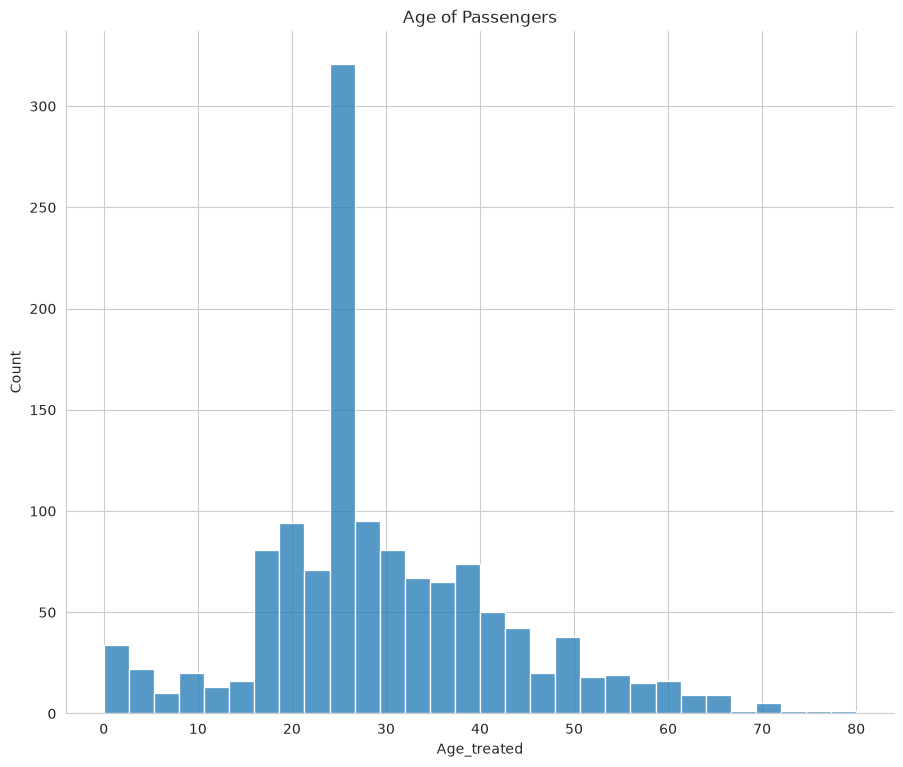

In [23]:
### Histogram
ax = sns.displot(titanic_df.Age_treated, kde= False)
column = 'Age_treated'
title_graph = 'Age of Passengers'
ax.set(xlabel= column, title= title_graph)
ax.figure.set_size_inches(10,8)

The vast majority of passengers were adults, with most falling within the **20–40 age range**. The age distribution does not appear to be symmetric, suggesting some degree of skewness.

Although the **Title** variable was not useful for inferring passengers’ age ranges, it may still be useful for explaining the target variable, **Survived**, since the analysis showed that women had a higher survival rate than men.

However, the **Title** variable requires some preprocessing because it contains a large number of categories with very few observations. Therefore, we chose to retain the most frequent titles—**Mr, Miss, Mrs, and Master**—while grouping all remaining titles into a single **Person** category.


In [24]:
### Removing categories with few observations from the Title variable.
titanic_df['Title'] = [n if n in ['Mr', 'Miss', 'Mrs', 'Master'] else 'Person' for n in titanic_df['Title']]
titanic_df.Title.unique()

<StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Person']
Length: 5, dtype: str

### SibSp

In [25]:
## SibSp
descr_column(titanic_df, 'SibSp')

Column: SibSp
Number of records in this df: 1309
Number of unique values: 7

What are the unique values: [1 0 3 4 2 5 8]

Number of null values: 0

Percentage of null values: 0.0 %

Value counts: 
SibSp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64


SibSp  Survived
0      No          44.67
       Yes         23.57
1      Yes         12.57
       No          10.89
2      No           1.68
       Yes          1.46
3      No           1.35
       Yes          0.45
4      No           1.68
       Yes          0.34
5      No           0.56
8      No           0.79
Name: count, dtype: float64

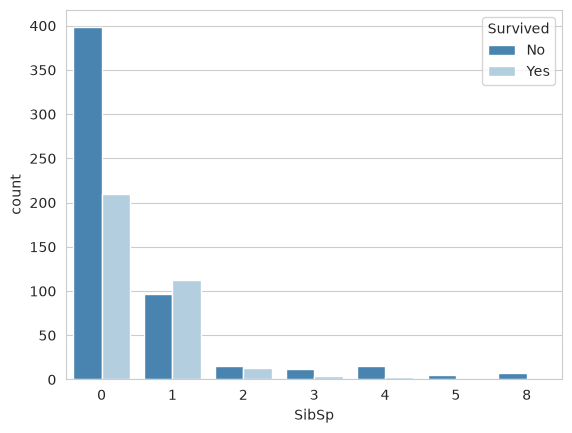

In [ ]:

columns = ['SibSp','Survived']

col_dic = {}

freq_var(titanic_df, columns, col_dic, var_resp_dic)

The **SibSp** variable does not contain any missing values. Therefore, it can be used directly in the model without requiring any preprocessing.


### Parch

In [27]:
## Parch
descr_column(titanic_df, 'Parch')

Column: Parch
Number of records in this df: 1309
Number of unique values: 8

What are the unique values: [0 1 2 5 3 4 6 9]

Number of null values: 0

Percentage of null values: 0.0 %

Value counts: 
Parch
0    1002
1     170
2     113
3       8
5       6
4       6
6       2
9       2
Name: count, dtype: int64


Parch  Survived
0      No          49.94
       Yes         26.15
1      Yes          7.30
       No           5.95
2      Yes          4.49
       No           4.49
3      Yes          0.34
       No           0.22
4      No           0.45
5      No           0.45
       Yes          0.11
6      No           0.11
Name: count, dtype: float64

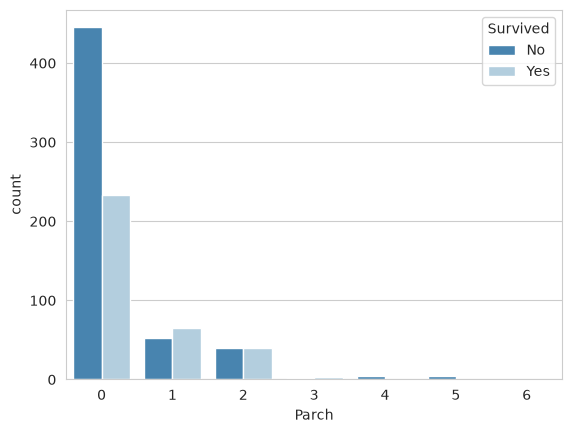

In [ ]:

columns = ['Parch','Survived']

col_dic = {}

freq_var(titanic_df, columns, col_dic, var_resp_dic)

The **Ticket** and **Cabin** columns contain passenger and cabin identification information, respectively. Since these variables do not provide meaningful predictive information for the model and may introduce noise or high cardinality, they will be excluded from the model-building process.


### Embarked

In [29]:
## Embarked
descr_column(titanic_df, 'Embarked')

Column: Embarked
Number of records in this df: 1309
Number of unique values: 3

What are the unique values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Number of null values: 2

Percentage of null values: 0.15 %

Value counts: 
Embarked
S    914
C    270
Q    123
Name: count, dtype: int64


In [30]:
## 
titanic_df[titanic_df.Embarked.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,train,Miss,38
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,train,Mrs,62


Since the majority of passengers embarked at **port S (914 passengers)** compared to the other ports, we chose to fill the missing values with **port S**.


In [ ]:

titanic_df['Embarked_treated'] = titanic_df['Embarked']
titanic_df.fillna({'Embarked_treated': 'S'}, inplace = True)
titanic_df[titanic_df.Embarked.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated,Embarked_treated
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,train,Miss,38,S
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,train,Mrs,62,S


Embarked_treated  Survived
C                 Yes         10.44
                  No           8.42
Q                 No           5.27
                  Yes          3.37
S                 No          47.92
                  Yes         24.58
Name: count, dtype: float64

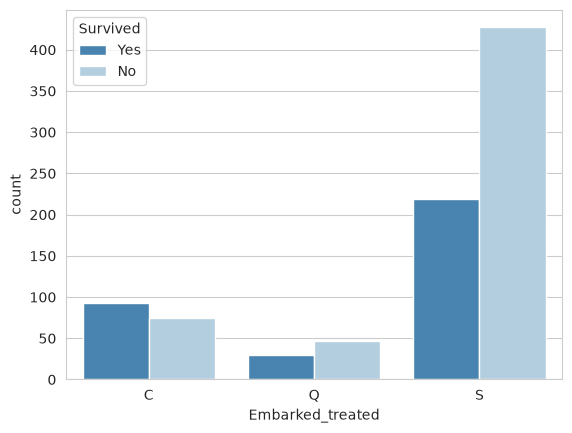

In [35]:

columns = ['Embarked_treated','Survived']

col_dic = {}
var_resp_dic = {0:"No",
                1:"Yes"}

freq_var(titanic_df, columns, col_dic, var_resp_dic)

In [36]:
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated,Embarked_treated
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,test,Mr,25,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,test,Person,39,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,test,Mr,38,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,test,Mr,25,S
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C,test,Master,25,C


### Fare

In [37]:
## Fare
descr_column(titanic_df, 'Fare')

Column: Fare
Number of records in this df: 1309
Number of unique values: 281

What are the unique values: [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   9.475   21.      41.5792  15.5     21.6792  17.8
  39.6875   7.8     76.7292  61.9792  27.75    46.9     80.      83.475
  27.9     15.2458   8.1583   8.6625  73.5     14.4542  56.4958   7.65
  29.      12.475    9.       9.5      7.7875  47.1     15.85    34.375
  61.175   20.575   34.6542  63.3583  23.      77.2875   8.6542   7.775
  24.15     9.825   14.4583 247.5208   7.1417  22.3583   6.975    7.05
  14.5     15.0458  26.2833   9.2167  79.2      6.75    11.5     36.75
   7.7958  12.525   66.6      7.3125  61.3792   7.7333  69.55    16.1
  15.75    20.525   55.      25.925   33.5 

In [38]:
titanic_df[titanic_df.Fare.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated,Embarked_treated
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,test,Mr,60,S


There is only one missing value in the **Fare** column, corresponding to a third-class passenger. Since the fare paid is directly related to the passenger's class, the missing value is filled with the **mean fare paid by third-class passengers**.


In [40]:
# Creating a copy of the Fare column
titanic_df['Fare_treated'] = titanic_df['Fare']

# Calculating the mean fare for third-class passengers
mean_fare_3 = titanic_df.loc[titanic_df['Pclass'] == 3, 'Fare'].mean()

# Filling missing Fare values with the mean fare for third-class passengers
titanic_df.loc[titanic_df['Fare_treated'].isna(), 'Fare_treated'] = mean_fare_3

# Checking the passenger whose original Fare value was missing
titanic_df[titanic_df['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Df,Title,Age_treated,Embarked_treated,Fare_treated
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,test,Mr,60,S,13.302889


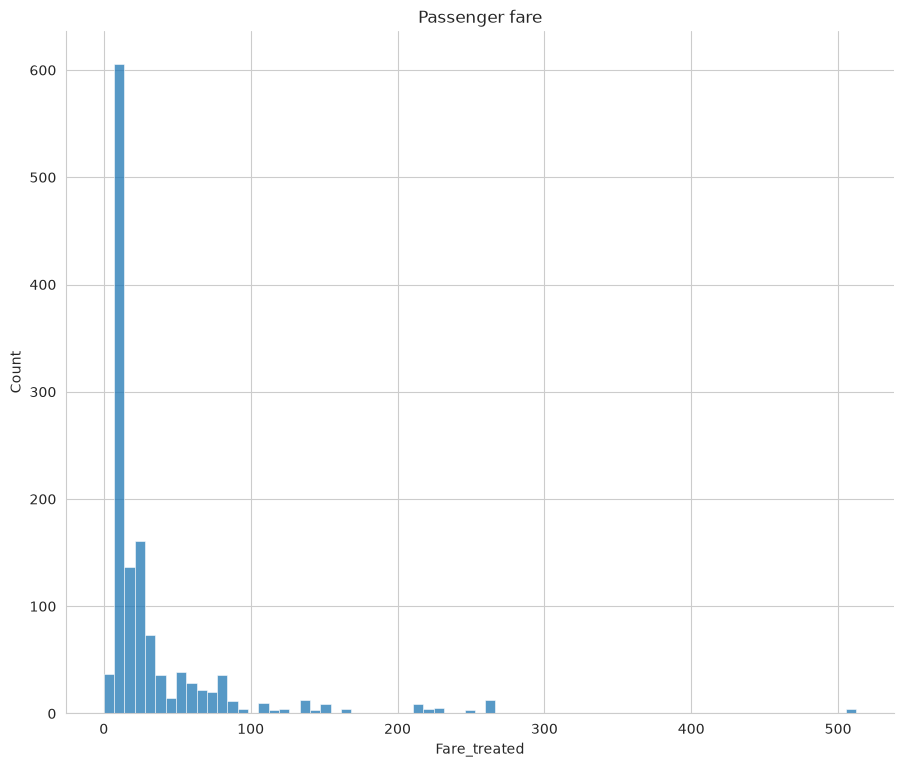

In [41]:
### Histogram
ax = sns.displot(titanic_df.Fare_treated, kde= False)
column = 'Fare_treated'
title_graph = 'Passenger fare'
ax.set(xlabel= column, title= title_graph)
ax.figure.set_size_inches(10,8)

In [42]:
### Selecting the variables to be used in the analysis.

df = titanic_df.copy()

df = df[['Survived', 
        'Pclass', 
        'Sex', 
        'Age_treated', 
        'SibSp', 
        'Parch',
        'Fare_treated',
        'Embarked_treated',
        'Title',
        'Df']]

## Transforming categorical variables into dummy variables.

df['Sex'] = df['Sex'].replace(['female', 'male'], [1, 0])
pclass = pd.get_dummies(df['Pclass'], prefix = "Pclass", drop_first = True)
title = pd.get_dummies(df['Title'], prefix = 'Title', drop_first = True)
embarked = pd.get_dummies(df['Embarked_treated'], prefix = 'Embarked', drop_first = True)

df_model = pd.concat([df, pclass, title, embarked], axis = 1)


del df
df_model.drop(['Pclass', 'Embarked_treated', 'Title'],axis='columns', inplace=True)

## Spliting train and test datasets
titanic_train = df_model.copy()
titanic_train = df_model.query('Df == "train"')


titanic_test = df_model.copy()
titanic_test = df_model.query('Df == "test"')


## Selection of the variables to be used in the analysis
titanic_train = titanic_train[['Survived', 
                               'Age_treated',
                               'SibSp',
                               'Parch',
                               'Fare_treated',
                               'Sex',
                               'Pclass_2',
                               'Pclass_3',
                               'Title_Miss',
                               'Title_Mr',
                               'Title_Mrs',
                               'Title_Person',
                               'Embarked_Q',
                               'Embarked_S']]

titanic_test = titanic_test[['Age_treated',
                               'SibSp',
                               'Parch',
                               'Fare_treated',
                               'Sex',
                               'Pclass_2',
                               'Pclass_3',
                               'Title_Miss',
                               'Title_Mr',
                               'Title_Mrs',
                               'Title_Person',
                               'Embarked_Q',
                               'Embarked_S']]

### Correcting data types in the variables.

titanic_train['Survived'] = titanic_train['Survived'].astype(int)


del df_model

titanic_train.head()

,Survived,Age_treated,SibSp,Parch,Fare_treated,Sex,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Person,Embarked_Q,Embarked_S
0,0,22,1,0,7.2500,0,False,True,False,True,False,False,False,True
1,1,38,1,0,71.2833,1,False,False,False,False,True,False,False,False
2,1,26,0,0,7.9250,1,False,True,True,False,False,False,False,True
3,1,35,1,0,53.1000,1,False,False,False,False,True,False,False,True
4,0,35,0,0,8.0500,0,False,True,False,True,False,False,False,True


In [43]:
titanic_test.head()

,Age_treated,SibSp,Parch,Fare_treated,Sex,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Person,Embarked_Q,Embarked_S
891,34,0,0,7.8292,0,False,True,False,True,False,False,True,False
892,47,1,0,7.0000,1,False,True,False,False,True,False,False,True
893,62,0,0,9.6875,0,True,False,False,True,False,False,True,False
894,27,0,0,8.6625,0,False,True,False,True,False,False,False,True
895,22,1,1,12.2875,1,False,True,False,False,True,False,False,True


<Axes: >

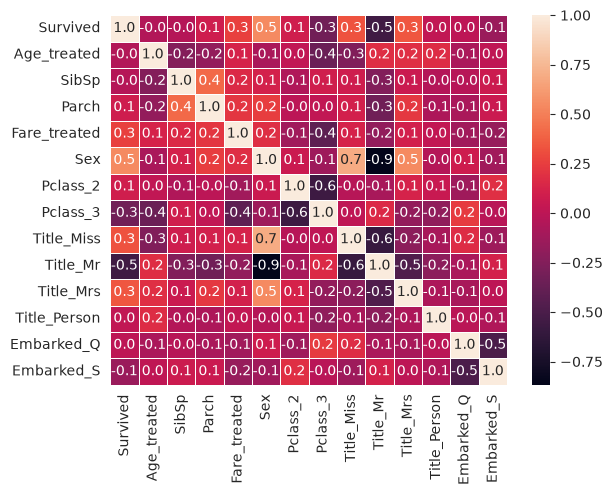

In [44]:
### Evaluating the correlation between the variables.

correlation = titanic_train.corr()
plot = sns.heatmap(correlation, annot = True, fmt=".1f", linewidths=.6)
plot

The correlation matrix indicates a **strong correlation between the `Sex` variable and several `Title` dummy variables**, particularly `Title_Mr` (-0.9) and `Title_Miss` (0.7). This suggests a high degree of redundancy between these features, which may introduce **multicollinearity** and reduce the efficiency and interpretability of the model.

Since highly correlated variables often provide overlapping information, one possible strategy is to remove redundant features without significantly reducing the model's predictive power. This can result in a **simpler and more parsimonious model**, while also reducing the risk of multicollinearity.


In [45]:
## Selection of the variables to be used in the analysis
titanic_train = titanic_train[['Survived', 
                               'Age_treated',
                               'SibSp',
                               'Parch',
                               'Fare_treated',
                               'Sex',
                               'Pclass_2',
                               'Pclass_3',
                               'Embarked_Q',
                               'Embarked_S']]

titanic_test = titanic_test[['Age_treated',
                               'SibSp',
                               'Parch',
                               'Fare_treated',
                               'Sex',
                               'Pclass_2',
                               'Pclass_3',
                               'Embarked_Q',
                               'Embarked_S']]
titanic_train.head()

,Survived,Age_treated,SibSp,Parch,Fare_treated,Sex,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,22,1,0,7.2500,0,False,True,False,True
1,1,38,1,0,71.2833,1,False,False,False,False
2,1,26,0,0,7.9250,1,False,True,False,True
3,1,35,1,0,53.1000,1,False,False,False,True
4,0,35,0,0,8.0500,0,False,True,False,True


<Axes: >

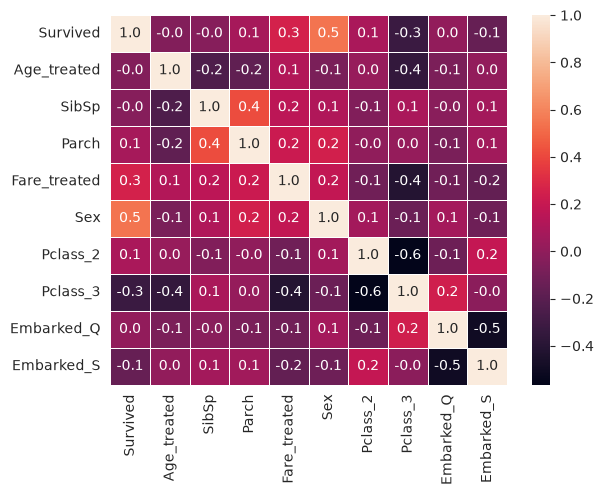

In [46]:
### Evaluating the correlation between the variables.
correlation = titanic_train.corr()
plot = sns.heatmap(correlation, annot = True, fmt=".1f", linewidths=.6)
plot

The remaining variables show some degree of correlation, but none appears to be sufficiently correlated to be considered redundant. Therefore, we have finalized the set of variables to be used in the classification model.


In [ ]:
### Saving the processed datasets to CSV files for future use.
titanic_train.to_csv('C:/Users/clari/OneDrive/Documentos/python_codigos/titanic_project/data/titanic_train.csv')
titanic_test.to_csv('C:/Users/clari/OneDrive/Documentos/python_codigos/titanic_project/data/titanic_test.csv')